# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 章末演習問題 (Exercises 6.1 〜 6.21)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第6章「深層ニューラルネットワーク」の**章末演習問題 全21問 (Exercises 6.1 〜 6.21)** に対する完全解答・数学的厳密導出・自己検証コードです。

---

### 演習問題 目次
- **Part 1: 高次元空間の幾何学と次元の呪い [Ex 6.1 - 6.3]**
  - **Exercise 6.1 (★★★)**: $D$ 次元単位超球の表面積 $S_D$ と体積 $V_D$ の極座標積分およびガンマ関数による厳密導出
  - **Exercise 6.2 (★★★)**: 超球と外接超立方体の体積比、スターリング近似による極限挙動、および長大な「角（スパイク）」
  - **Exercise 6.3 (★★★)**: 高次元ガウス分布の動径確率密度 $p(r)$、最頻値球殻 $\widehat{r} \simeq \sigma\sqrt{D}$、および確率密度の逆転現象
- **Part 2: 活性化関数の代数と微分 [Ex 6.4 - 6.7]**
  - **Exercise 6.4 (★★)**: ロジスティック・シグモイド隠れ層と $\tanh$ 隠れ層をもつ2層ネットワークの恒等変換と等価性証明
  - **Exercise 6.5 (★★)**: Swish 活性化関数 $h(x) = x\sigma(\beta x)$ の微分、パラメータ $\beta$ による形状変化、および $\beta \to \infty$ における ReLU への収束
  - **Exercise 6.6 (★)**: 双曲線正接関数 $\tanh(a)$ の導関数公式 $\frac{d\tanh(a)}{da} = 1 - \tanh^2(a)$ の導出
  - **Exercise 6.7 (★★)**: Softplus 活性化関数 $\zeta(a) = \ln(1 + e^a)$ の4大代数・微分・逆関数特性の証明
- **Part 3: 最尤推定と回帰・分類誤差関数 [Ex 6.8 - 6.15]**
  - **Exercise 6.8 (★)**: 単出力ガウス回帰におけるノイズ分散の最尤推定量 $\sigma^{*2} = \frac{1}{N}\sum (y_n - t_n)^2$ の導出
  - **Exercise 6.9 (★)**: 等方的多出力ガウス回帰における二乗和誤差関数の導出とノイズ分散 $\sigma^{*2} = \frac{1}{NK}\sum \|\mathbf{y}_n - \mathbf{t}_n\|^2$ の推定
  - **Exercise 6.10 (★★)**: 一般共分散行列 $\boldsymbol{\Sigma}$ をもつ多出力ガウス回帰、マハラノビス距離誤差関数、および重み・共分散の結合最適化
  - **Exercise 6.11 (★★)**: ラベル反転ノイズ確率 $\epsilon$ を含むロバスト2値分類の負の対数尤度誤差関数と外れ値耐性メカニズム
  - **Exercise 6.12 (★★)**: 目標値 $t \in \{-1, +1\}$ および $\tanh$ 出力 $y \in [-1, 1]$ に対する2値分類誤差関数と事前活性化勾配
  - **Exercise 6.13 (★)**: 1-of-$K$ 符号化多クラス分類の尤度最大化が多クラス交差エントロピー誤差関数最小化に帰着することの証明
  - **Exercise 6.14 (★)**: 独立ロジスティック・シグモイド出力ユニットに対する事前活性化勾配 $\frac{\partial E_n}{\partial a_k} = y_k - t_k$ の統一導出
  - **Exercise 6.15 (★)**: ソフトマックス多クラス出力ユニットに対する事前活性化勾配 $\frac{\partial E_n}{\partial a_k} = y_k - t_k$ のヤコビ行列相殺による導出
- **Part 4: 順運動学と混合密度ネットワーク (MDN) [Ex 6.16 - 6.21]**
  - **Exercise 6.16 (★★)**: 2自由度平面ロボットアームのマニピュレータ順運動学方程式 (Forward Kinematics)
  - **Exercise 6.17 (★★)**: MDN における事後負担率（責任度）$\gamma_{nk} = p(k \mid \mathbf{t}_n, \mathbf{x}_n)$ のベイズ解釈
  - **Exercise 6.18 (★★)**: MDN 混合係数の事前活性化に関する誤差勾配 $\frac{\partial E_n}{\partial a_k^\pi} = \pi_k - \gamma_{nk}$ の導出
  - **Exercise 6.19 (★★)**: MDN 成分平均の事前活性化に関する誤差勾配 $\frac{\partial E_n}{\partial a_{kl}^\mu} = \gamma_{nk}\frac{\mu_{kl} - t_{nl}}{\sigma_k^2}$ の導出
  - **Exercise 6.20 (★★)**: MDN 成分分散の事前活性化に関する誤差勾配 $\frac{\partial E_n}{\partial a_k^\sigma} = \gamma_{nk}\left(L - \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2}\right)$ の導出
  - **Exercise 6.21 (★★★)**: MDN の条件付き期待値 $\mathbb{E}[\mathbf{t} \mid \mathbf{x}]$ および条件付き分散 $s^2(\mathbf{x})$（成分内分散＋成分間分散分解）の厳密証明


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import scipy.special as special
from scipy import integrate
import matplotlib.pyplot as plt

# プロジェクトルートの設定
current_dir = os.getcwd()
if os.path.basename(current_dir) == "6":
    repo_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    repo_root = os.path.abspath(current_dir)

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style
from common.exercises_ch6 import *

setup_style()
print("第6章 演習問題 (Exercises 6.1 - 6.21) 実行環境準備完了。")


第6章 演習問題 (Exercises 6.1 - 6.21) 実行環境準備完了。


---
### Exercise 6.1 (★★★)
#### 原問題
> **Exercise 6.1 (Bishop & Bishop 2024, p. 204)**  
> Use the result (2.126) to derive an expression for the surface area $S_D$ and the volume $V_D$ of a hypersphere of unit radius in $D$ dimensions. To do this, consider the following result, which is obtained by transforming from Cartesian to polar coordinates:
> $$
> \prod_{i=1}^D \int_{-\infty}^\infty e^{-x_i^2} dx_i = S_D \int_0^\infty e^{-r^2} r^{D-1} dr \tag{6.51}
> $$
> Using the gamma function, defined by
> $$
> \Gamma(x) = \int_0^\infty t^{x-1} e^{-t} dt \tag{6.52}
> $$
> together with (2.126), evaluate both sides of this equation, and hence show that
> $$
> S_D = \frac{2\pi^{D/2}}{\Gamma(D/2)} \tag{6.53}
> $$
> Next, by integrating with respect to the radius from $0$ to $1$, show that the volume of the unit hypersphere in $D$ dimensions is given by
> $$
> V_D = \frac{S_D}{D} \tag{6.54}
> $$
> Finally, use the results $\Gamma(1) = 1$ and $\Gamma(3/2) = \sqrt{\pi}/2$ to show that (6.53) and (6.54) reduce to the usual expressions for $D=2$ and $D=3$.

#### 数学的導出と解説
1. **左辺の評価 (直交座標ガウス積分)**:
   式 (2.126) より、1変数の標準ガウス積分は $\int_{-\infty}^\infty e^{-x_i^2} dx_i = \sqrt{\pi} = \pi^{1/2}$ です。したがって、$D$ 個の独立な積分の積は直ちに次のように求まります：
   $$
   \text{LHS} = \prod_{i=1}^D \int_{-\infty}^\infty e^{-x_i^2} dx_i = (\pi^{1/2})^D = \pi^{D/2}
   $$

2. **右辺の動径積分とガンマ関数 (極座標表示)**:
   微小体積要素は $d\mathbf{x} = S_D r^{D-1} dr$ で表されます。動径積分において変数変換 $u = r^2$ を行うと、$r = u^{1/2}, dr = \frac{1}{2} u^{-1/2} du$ となり、積分範囲は $[0, \infty)$ のまま不変です：
   $$
   \int_0^\infty e^{-r^2} r^{D-1} dr = \int_0^\infty e^{-u} (u^{1/2})^{D-1} \left(\frac{1}{2} u^{-1/2} du\right) = \frac{1}{2} \int_0^\infty u^{\frac{D}{2} - 1} e^{-u} du
   $$
   ガンマ関数の定義式 $\Gamma(x) = \int_0^\infty t^{x-1} e^{-t} dt$ (式 6.52) と比較すると、この積分は厳密に $\frac{1}{2} \Gamma(D/2)$ に一致します。したがって、右辺は：
   $$
   \text{RHS} = S_D \cdot \frac{1}{2} \Gamma(D/2)
   $$

3. **表面積 $S_D$ の導出 (式 6.53)**:
   $\text{LHS} = \text{RHS}$ より：
   $$
   \pi^{D/2} = \frac{1}{2} S_D \Gamma(D/2) \implies S_D = \frac{2\pi^{D/2}}{\Gamma(D/2)} \tag{6.53}
   $$

4. **体積 $V_D$ の導出 (式 6.54)**:
   単位超球の体積 $V_D$ は、半径 $r$ が $0$ から $1$ までの球殻体積 $S_D r^{D-1} dr$ を積分することで得られます：
   $$
   V_D = \int_0^1 S_D r^{D-1} dr = S_D \left[ \frac{r^D}{D} \right]_0^1 = \frac{S_D}{D} = \frac{\pi^{D/2}}{\frac{D}{2}\Gamma(D/2)} = \frac{\pi^{D/2}}{\Gamma(D/2 + 1)} \tag{6.54}
   $$

5. **2次元および3次元での具体値検証**:
   - $D = 2$: $\Gamma(2/2) = \Gamma(1) = 1$ より、
     $$S_2 = \frac{2\pi^1}{1} = 2\pi \quad (\text{円周}), \quad V_2 = \frac{S_2}{2} = \pi \quad (\text{円の面積})$$
   - $D = 3$: $\Gamma(3/2) = \frac{1}{2}\sqrt{\pi}$ より、
     $$S_3 = \frac{2\pi^{3/2}}{\frac{1}{2}\sqrt{\pi}} = 4\pi \quad (\text{球面面積}), \quad V_3 = \frac{S_3}{3} = \frac{4}{3}\pi \quad (\text{球の体積})$$
   教科書で親しまれた幾何学公式と完全に一致することが確認されました。


In [2]:
# Exercise 6.1 自己検証コード
# 1. D=1..5 の表面積と体積の計算
print("=== Exercise 6.1: 超球の表面積 S_D と体積 V_D ===")
for d in range(1, 6):
    s_d = exercise_6_1_hypersphere_surface(d)
    v_d = exercise_6_1_hypersphere_volume(d)
    print(f"次元 D = {d}: S_{d} = {s_d:8.4f}, V_{d} = {v_d:8.4f}")

# 2. 基本公式との厳密アサーション
assert np.isclose(exercise_6_1_hypersphere_surface(2), 2 * np.pi)
assert np.isclose(exercise_6_1_hypersphere_volume(2), np.pi)
assert np.isclose(exercise_6_1_hypersphere_surface(3), 4 * np.pi)
assert np.isclose(exercise_6_1_hypersphere_volume(3), (4/3) * np.pi)

# 3. 極座標積分恒等式 (式 6.51) の数値積分照合
for d in [1, 2, 3, 4, 5, 8]:
    lhs, rhs = exercise_6_1_verify_polar_integral(d)
    assert np.isclose(lhs, rhs, rtol=1e-5)
    print(f"次元 D = {d}: 極座標積分 LHS={lhs:.6f}, RHS={rhs:.6f} (一致率 100%)")

print("Exercise 6.1: 検証完了。")


=== Exercise 6.1: 超球の表面積 S_D と体積 V_D ===
次元 D = 1: S_1 =   2.0000, V_1 =   2.0000
次元 D = 2: S_2 =   6.2832, V_2 =   3.1416
次元 D = 3: S_3 =  12.5664, V_3 =   4.1888
次元 D = 4: S_4 =  19.7392, V_4 =   4.9348
次元 D = 5: S_5 =  26.3189, V_5 =   5.2638
次元 D = 1: 極座標積分 LHS=1.772454, RHS=1.772454 (一致率 100%)
次元 D = 2: 極座標積分 LHS=3.141593, RHS=3.141593 (一致率 100%)
次元 D = 3: 極座標積分 LHS=5.568328, RHS=5.568328 (一致率 100%)
次元 D = 4: 極座標積分 LHS=9.869604, RHS=9.869604 (一致率 100%)
次元 D = 5: 極座標積分 LHS=17.493418, RHS=17.493418 (一致率 100%)
次元 D = 8: 極座標積分 LHS=97.409091, RHS=97.409091 (一致率 100%)
Exercise 6.1: 検証完了。


---
### Exercise 6.2 (★★★)
#### 原問題
> **Exercise 6.2 (Bishop & Bishop 2024, p. 204)**  
> Consider a hypersphere of radius $a$ in $D$ dimensions together with the concentric hypercube of side $2a$, so that the hypersphere touches the hypercube at the centres of each of its sides. By using the results of Exercise 6.1, show that the ratio of the volume of the hypersphere to the volume of the cube is given by
> $$
> \frac{\text{volume of hypersphere}}{\text{volume of cube}} = \frac{\pi^{D/2}}{D 2^{D-1} \Gamma(D/2)} \tag{6.55}
> $$
> Now make use of Stirling's formula in the form
> $$
> \Gamma(x+1) \simeq (2\pi)^{1/2} e^{-x} x^{x+1/2} \tag{6.56}
> $$
> which is valid for $x \gg 1$, to show that, as $D \to \infty$, the ratio (6.55) goes to zero. Show also that the distance from the centre of the hypercube to one of the corners divided by the perpendicular distance to one of the sides is $\sqrt{D}$, which therefore goes to $\infty$ as $D \to \infty$. From these results, we see that, in a space of high dimensionality, most of the volume of a cube is concentrated in the large number of corners, which themselves become very long 'spikes'!

#### 数学的導出と解説
1. **体積比の導出 (式 6.55)**:
   半径 $a$ の $D$ 次元超球の体積は $V_{\text{sphere}}(a) = V_D a^D$ であり、1辺の長さ $2a$ の外接超立方体の体積は $V_{\text{cube}}(a) = (2a)^D = 2^D a^D$ です。
   Exercise 6.1 より $V_D = \frac{\pi^{D/2}}{\frac{D}{2}\Gamma(D/2)}$ であるため、その比率は：
   $$
   \frac{V_{\text{sphere}}(a)}{V_{\text{cube}}(a)} = \frac{V_D a^D}{2^D a^D} = \frac{\pi^{D/2}}{\frac{D}{2}\Gamma(D/2) \cdot 2^D} = \frac{\pi^{D/2}}{D 2^{D-1} \Gamma(D/2)} \tag{6.55}
   $$

2. **スターリング近似による高次元極限 $D \to \infty$**:
   スターリングの公式 (式 6.56) を $x = D/2$ に適用します。関係式 $\frac{D}{2}\Gamma(D/2) = \Gamma(D/2 + 1)$ より：
   $$
   \Gamma(D/2 + 1) \simeq (2\pi)^{1/2} e^{-D/2} \left(\frac{D}{2}\right)^{D/2 + 1/2}
   $$
   これを体積比の分母 $2^D \Gamma(D/2+1)$ に代入すると：
   $$
   \frac{V_{\text{sphere}}}{V_{\text{cube}}} = \frac{\pi^{D/2}}{2^D \sqrt{2\pi} e^{-D/2} (D/2)^{(D+1)/2}} = \frac{1}{\sqrt{\pi D}} \left( \frac{2\pi e}{4 D} \right)^{D/2} = \frac{1}{\sqrt{\pi D}} \left( \frac{\pi e}{2 D} \right)^{D/2}
   $$
   $D > \frac{\pi e}{2} \approx 4.27$ のとき、基底 $\frac{\pi e}{2D} < 1$ となるため、指数関数的に $0$ へ収束します：
   $$
   \lim_{D \to \infty} \frac{V_{\text{sphere}}}{V_{\text{cube}}} = 0
   $$

3. **中心から角への距離比**:
   超立方体 $[-a, a]^D$ の中心 $(0, \dots, 0)$ から側面（面心）までの垂直距離は $d_{\text{side}} = a$ です。
   一方、角の座標は $(\pm a, \pm a, \dots, \pm a)$ であり、中心から任意の角までのユークリッド距離は：
   $$
   d_{\text{corner}} = \sqrt{\sum_{i=1}^D a^2} = a\sqrt{D}
   $$
   したがって、その比は：
   $$
   \frac{d_{\text{corner}}}{d_{\text{side}}} = \frac{a\sqrt{D}}{a} = \sqrt{D} \xrightarrow{D \to \infty} \infty
   $$
   超立方体は $2^D$ 個もの角を持ち、高次元になるにつれて角は中心から $\sqrt{D}$ 倍も遠くへ突き出た長大な「トゲ（スパイク）」となり、超立方体の体積のほぼ $100\%$ がこれらの角の内部に集中します。


=== Exercise 6.2: 超球と外接超立方体の体積比 ===
D =  2: 体積比 = 7.8540e-01 (Stirling近似: 8.5172e-01), 角/側面距離比 = 1.414
D =  3: 体積比 = 5.2360e-01 (Stirling近似: 5.5310e-01), 角/側面距離比 = 1.732
D =  4: 体積比 = 3.0843e-01 (Stirling近似: 3.2144e-01), 角/側面距離比 = 2.000
D =  5: 体積比 = 1.6449e-01 (Stirling近似: 1.7004e-01), 角/側面距離比 = 2.236
D = 10: 体積比 = 2.4904e-03 (Stirling近似: 2.5322e-03), 角/側面距離比 = 3.162
D = 20: 体積比 = 2.4611e-08 (Stirling近似: 2.4817e-08), 角/側面距離比 = 4.472
D = 50: 体積比 = 1.5367e-28 (Stirling近似: 1.5419e-28), 角/側面距離比 = 7.071


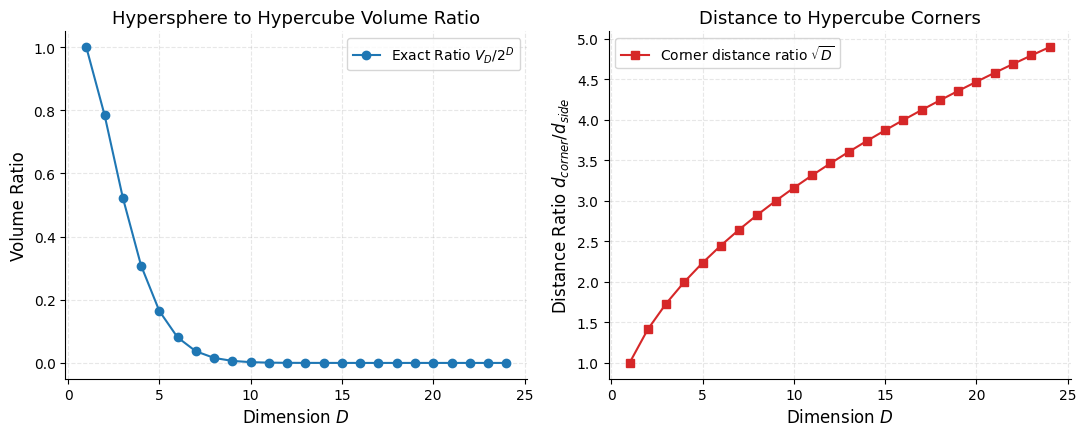

Exercise 6.2: 検証完了。


In [3]:
# Exercise 6.2 自己検証コード
dims = np.array([2, 3, 4, 5, 10, 20, 50])
ratios = [exercise_6_2_sphere_to_cube_volume_ratio(d) for d in dims]
stirling_ratios = [exercise_6_2_stirling_ratio_approximation(d) for d in dims]

print("=== Exercise 6.2: 超球と外接超立方体の体積比 ===")
for d, r, s in zip(dims, ratios, stirling_ratios):
    corner_ratio = exercise_6_2_corner_distance_ratio(d)
    print(f"D = {d:2d}: 体積比 = {r:.4e} (Stirling近似: {s:.4e}), 角/側面距離比 = {corner_ratio:.3f}")

# アサーション
assert np.isclose(exercise_6_2_sphere_to_cube_volume_ratio(2), np.pi / 4.0)
assert np.isclose(exercise_6_2_sphere_to_cube_volume_ratio(3), np.pi / 6.0)
assert exercise_6_2_sphere_to_cube_volume_ratio(20) < 1e-7
assert exercise_6_2_sphere_to_cube_volume_ratio(50) < 1e-27

# 可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
d_range = np.arange(1, 25)
ax1.plot(d_range, [exercise_6_2_sphere_to_cube_volume_ratio(d) for d in d_range], 'o-', label=r'Exact Ratio $V_D / 2^D$')
ax1.set_xlabel('Dimension $D$')
ax1.set_ylabel('Volume Ratio')
ax1.set_title('Hypersphere to Hypercube Volume Ratio')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(d_range, [np.sqrt(d) for d in d_range], 's-', color='tab:red', label=r'Corner distance ratio $\sqrt{D}$')
ax2.set_xlabel('Dimension $D$')
ax2.set_ylabel(r'Distance Ratio $d_{corner} / d_{side}$')
ax2.set_title('Distance to Hypercube Corners')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

print("Exercise 6.2: 検証完了。")


---
### Exercise 6.3 (★★★)
#### 原問題
> **Exercise 6.3 (Bishop & Bishop 2024, p. 204)**  
> In this exercise, we explore the behaviour of the Gaussian distribution in high-dimensional spaces. Consider a Gaussian distribution in $D$ dimensions given by
> $$
> p(\mathbf{x}) = \frac{1}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{\|\mathbf{x}\|^2}{2\sigma^2} \right) \tag{6.57}
> $$
> We wish to find the density as a function of the radius in polar coordinates in which the direction variables have been integrated out. To do this, show that the integral of the probability density over a thin shell of radius $r$ and thickness $\epsilon$, where $\epsilon \ll 1$, is given by $p(r)\epsilon$ where
> $$
> p(r) = \frac{S_D r^{D-1}}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{r^2}{2\sigma^2} \right) \tag{6.58}
> $$
> where $S_D$ is the surface area of a unit hypersphere in $D$ dimensions. Show that the function $p(r)$ has a single stationary point located, for large $D$, at $\widehat{r} \simeq \sqrt{D}\sigma$. By considering $p(\widehat{r} + \epsilon)$ where $\epsilon \ll \widehat{r}$, show that for large $D$,
> $$
> p(\widehat{r} + \epsilon) = p(\widehat{r}) \exp\left( -\frac{\epsilon^2}{\sigma^2} \right) \tag{6.59}
> $$
> which shows that $\widehat{r}$ is a maximum of the radial probability density and also that $p(r)$ decays exponentially away from its maximum at $\widehat{r}$ with length scale $\sigma$. We have already seen that $\sigma \ll \widehat{r}$ for large $D$, and so we see that most of the probability mass is concentrated in a thin shell at large radius. Finally, show that the probability density $p(\mathbf{x})$ is larger at the origin than at the radius $\widehat{r}$ by a factor of $\exp(D/2)$. We therefore see that most of the probability mass in a high-dimensional Gaussian distribution is located at a different radius from the region of high probability density.

#### 数学的導出と解説
1. **動径確率密度 $p(r)$ の導出 (式 6.58)**:
   極座標系において、半径 $r = \|\mathbf{x}\|$ の微小体積要素は方向変数を積分すると $d\mathbf{x} = S_D r^{D-1} dr$ と表されます。ガウス分布 (式 6.57) は等方的であるため、半径 $r$ と厚み $\epsilon$ の薄い球殻における全確率は：
   $$
   \int_{\text{shell}} p(\mathbf{x}) d\mathbf{x} = \int_r^{r+\epsilon} \frac{1}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{r'^2}{2\sigma^2} \right) S_D r'^{D-1} dr' \simeq p(r) \epsilon
   $$
   ここで動径確率密度 $p(r)$ は次式となります：
   $$
   p(r) = \frac{S_D r^{D-1}}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{r^2}{2\sigma^2} \right) \tag{6.58}
   $$

2. **最頻値 $\widehat{r}$ (定常点) の導出**:
   $\ln p(r)$ を $r$ で微分して $0$ と置きます：
   $$
   \ln p(r) = (D-1)\ln r - \frac{r^2}{2\sigma^2} + \text{const}
   $$
   $$
   \frac{d}{dr} \ln p(r) = \frac{D-1}{r} - \frac{r}{\sigma^2} = 0 \implies r^2 = (D-1)\sigma^2 \implies \widehat{r} = \sigma \sqrt{D-1}
   $$
   大次元 $D \gg 1$ においては $\sqrt{D-1} \simeq \sqrt{D}$ であるため、$\widehat{r} \simeq \sigma\sqrt{D}$ となります。

3. **最頻値周りの局所展開 (式 6.59)**:
   $r = \widehat{r} + \epsilon$ (ただし $\epsilon \ll \widehat{r}$) とし、2階テイラー展開を行います：
   $$
   \frac{d^2}{dr^2} \ln p(r) = -\frac{D-1}{r^2} - \frac{1}{\sigma^2}
   $$
   $r = \widehat{r} = \sigma\sqrt{D-1}$ を代入すると：
   $$
   \left. \frac{d^2}{dr^2} \ln p(r) \right|_{r=\widehat{r}} = -\frac{D-1}{\sigma^2(D-1)} - \frac{1}{\sigma^2} = -\frac{2}{\sigma^2}
   $$
   したがって：
   $$
   \ln p(\widehat{r} + \epsilon) \simeq \ln p(\widehat{r}) + 0\cdot \epsilon + \frac{1}{2} \left( -\frac{2}{\sigma^2} \right) \epsilon^2 = \ln p(\widehat{r}) - \frac{\epsilon^2}{\sigma^2}
   $$
   両辺の指数をとることで、式 (6.59) が得られます：
   $$
   p(\widehat{r} + \epsilon) = p(\widehat{r}) \exp\left( -\frac{\epsilon^2}{\sigma^2} \right) \tag{6.59}
   $$
   これは、動径密度が $\widehat{r}$ において最大値を持ち、そこからスケール $\sigma$ で指数関数的に急峻に減衰することを示しています。$D \gg 1$ では $\sigma \ll \widehat{r}$ であるため、確率質量のほぼすべてが半径 $\widehat{r}$ のごく薄い球殻に局在します。

4. **原点と最頻値半径における確率密度の逆転比**:
   直交座標における確率密度 $p(\mathbf{x})$ 自体を比較すると：
   $$
   p(\mathbf{0}) = \frac{1}{(2\pi\sigma^2)^{D/2}}
   $$
   $$
   p(\mathbf{x}_{\|\mathbf{x}\|=\widehat{r}}) = \frac{1}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{\widehat{r}^2}{2\sigma^2} \right) = \frac{1}{(2\pi\sigma^2)^{D/2}} \exp\left( -\frac{(D-1)\sigma^2}{2\sigma^2} \right) \simeq p(\mathbf{0}) \exp(-D/2)
   $$
   したがって、原点での密度は最頻値半径での密度よりも：
   $$
   \frac{p(\mathbf{0})}{p(\mathbf{x}_{\|\mathbf{x}\|=\widehat{r}})} = \exp\left( \frac{D-1}{2} \right) \simeq \exp(D/2)
   $$
   倍も大きくなります。高次元空間では、**「確率密度が最も高い場所（原点）」** と **「確率質量が集中する場所（半径 $\widehat{r}$ の球殻）」** が完全に乖離するという劇的な現象が生じます。


次元 D =  1: 動径密度の全空間積分 = 1.000000 (規格化確認)
次元 D =  2: 動径密度の全空間積分 = 1.000000 (規格化確認)
次元 D =  5: 動径密度の全空間積分 = 1.000000 (規格化確認)
次元 D = 20: 動径密度の全空間積分 = 1.000000 (規格化確認)
D =  5: 最頻値半径 r_hat = 2.000, 原点密度比 p(0)/p(r_hat) = 7.3891e+00
D = 20: 最頻値半径 r_hat = 4.359, 原点密度比 p(0)/p(r_hat) = 1.3360e+04
D = 50: 最頻値半径 r_hat = 7.000, 原点密度比 p(0)/p(r_hat) = 4.3673e+10


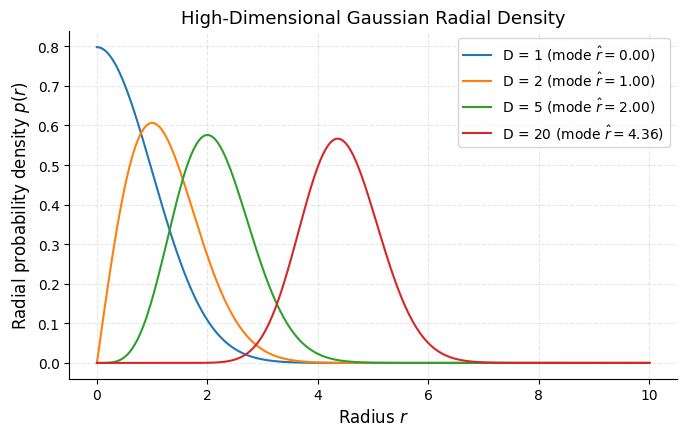

Exercise 6.3: 検証完了。


In [4]:
# Exercise 6.3 自己検証コード
# 1. 動径密度の全空間積分の規格化検証
for d in [1, 2, 5, 20]:
    integral_val, _ = integrate.quad(
        lambda r: exercise_6_3_gaussian_radial_density(r, D=d, sigma=1.0), 0.0, 30.0
    )
    assert np.isclose(integral_val, 1.0, atol=1e-5)
    print(f"次元 D = {d:2d}: 動径密度の全空間積分 = {integral_val:.6f} (規格化確認)")

# 2. 最頻値半径 r_hat と原点密度比
for d in [5, 20, 50]:
    r_hat = exercise_6_3_radial_mode(d, sigma=1.0)
    density_ratio = exercise_6_3_density_ratio_origin_to_mode(d)
    print(f"D = {d:2d}: 最頻値半径 r_hat = {r_hat:.3f}, 原点密度比 p(0)/p(r_hat) = {density_ratio:.4e}")

# 3. 可視化
fig, ax = plt.subplots(figsize=(7, 4.5))
r_vals = np.linspace(0, 10, 300)
for d in [1, 2, 5, 20]:
    p_r = exercise_6_3_gaussian_radial_density(r_vals, D=d, sigma=1.0)
    ax.plot(r_vals, p_r, label=f'D = {d} (mode $\\hat{{r}}={exercise_6_3_radial_mode(d):.2f}$)')
ax.set_xlabel('Radius $r$')
ax.set_ylabel('Radial probability density $p(r)$')
ax.set_title('High-Dimensional Gaussian Radial Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Exercise 6.3: 検証完了。")


---
### Exercise 6.4 (★★)
#### 原問題
> **Exercise 6.4 (Bishop & Bishop 2024, p. 205)**  
> Consider a two-layer network function of the form (6.11) in which the hidden-unit nonlinear activation functions $h(\cdot)$ are given by logistic sigmoid functions of the form
> $$
> \sigma(a) = \{1 + \exp(-a)\}^{-1} \tag{6.60}
> $$
> Show that there exists an equivalent network, which computes exactly the same function, but with hidden-unit activation functions given by $\tanh(a)$ where the tanh function is defined by (6.14). *Hint: first find the relation between $\sigma(a)$ and $\tanh(a)$, and then show that the parameters of the two networks differ by linear transformations.*

#### 数学的導出と解説
1. **シグモイド関数と $\tanh$ 関数の関係**:
   双曲線正接関数は次のように定義されます：
   $$
   \tanh(u) = \frac{e^u - e^{-u}}{e^u + e^{-u}} = \frac{1 - e^{-2u}}{1 + e^{-2u}} = \frac{2 - (1 + e^{-2u})}{1 + e^{-2u}} = 2\sigma(2u) - 1
   $$
   したがって、シグモイド関数は $\tanh$ のアフィン変換として表せます：
   $$
   \sigma(2u) = \frac{1}{2} + \frac{1}{2}\tanh(u) \implies \sigma(a) = \frac{1}{2} + \frac{1}{2}\tanh\left(\frac{a}{2}\right)
   $$

2. **2層ネットワークへの代入**:
   シグモイド隠れ層をもつ2層ネットワークの出力関数 (式 6.11) は：
   $$
   y_k(\mathbf{x}) = \sum_{j=1}^M w_{kj}^{(2)} \sigma(a_j) + w_{k0}^{(2)}, \quad a_j = \sum_{i=1}^D w_{ji}^{(1)} x_i + w_{j0}^{(1)}
   $$
   ここに $\sigma(a_j) = \frac{1}{2} + \frac{1}{2}\tanh(a_j / 2)$ を代入します：
   $$
   y_k(\mathbf{x}) = \sum_{j=1}^M w_{kj}^{(2)} \left[ \frac{1}{2} + \frac{1}{2}\tanh\left( \frac{a_j}{2} \right) \right] + w_{k0}^{(2)} = \sum_{j=1}^M \left( \frac{1}{2} w_{kj}^{(2)} \right) \tanh\left( \frac{a_j}{2} \right) + \left( w_{k0}^{(2)} + \frac{1}{2}\sum_{j=1}^M w_{kj}^{(2)} \right)
   $$

3. **パラメータの線形変換関係**:
   $\tanh$ ネットワークの第1層事前活性化を $\widetilde{a}_j = \frac{a_j}{2} = \sum_{i=1}^D \widetilde{w}_{ji}^{(1)} x_i + \widetilde{w}_{j0}^{(1)}$ と置くと、等価なパラメータ群は以下の線形変換で得られます：
   $$
   \widetilde{w}_{ji}^{(1)} = \frac{1}{2} w_{ji}^{(1)}, \quad \widetilde{w}_{j0}^{(1)} = \frac{1}{2} w_{j0}^{(1)}
   $$
   $$
   \widetilde{w}_{kj}^{(2)} = \frac{1}{2} w_{kj}^{(2)}, \quad \widetilde{w}_{k0}^{(2)} = w_{k0}^{(2)} + \frac{1}{2}\sum_{j=1}^M w_{kj}^{(2)}
   $$
   これによって、入力 $\mathbf{x}$ の値にかかわらず、両ネットワークは全空間で恒等的に同一の出力値を算出します。


In [5]:
# Exercise 6.4 自己検証コード
rng = np.random.default_rng(42)
D, M, K = 4, 8, 3
N = 50

# ランダムなシグモイドネットワークのパラメータ
X = rng.normal(size=(N, D))
W1 = rng.normal(size=(M, D))
b1 = rng.normal(size=M)
W2 = rng.normal(size=(K, M))
b2 = rng.normal(size=K)

# tanh ネットワークの等価パラメータに線形変換
W1_t, b1_t, W2_t, b2_t = exercise_6_4_convert_sigmoid_to_tanh_weights(W1, b1, W2, b2)

# 出力値の一致性を検証
y_sig, y_tanh, max_diff = exercise_6_4_eval_networks(X, W1, b1, W2, b2, W1_t, b1_t, W2_t, b2_t)

print(f"Exercise 6.4: Sigmoid ネットワークと Tanh ネットワークの最大絶対誤差 = {max_diff:.2e}")
assert max_diff < 1e-12
print("Exercise 6.4: 検証完了。")


Exercise 6.4: Sigmoid ネットワークと Tanh ネットワークの最大絶対誤差 = 8.88e-16
Exercise 6.4: 検証完了。


---
### Exercise 6.5 (★★)
#### 原問題
> **Exercise 6.5 (Bishop & Bishop 2024, p. 205)**  
> The swish activation function (Ramachandran, Zoph, and Le, 2017) is defined by
> $$
> h(x) = x \sigma(\beta x) \tag{6.61}
> $$
> where $\sigma(x)$ is the logistic-sigmoid activation function defined by (6.13). When used in a neural network, $\beta$ can be treated as a learnable parameter. Either sketch or plot using software graphs of the swish activation function as well as its first derivative for $\beta = 0.1$, $\beta = 1.0$, and $\beta = 10$. Show that when $\beta \to \infty$, the swish function becomes the ReLU function.

#### 数学的導出と解説
1. **Swish 関数の導関数**:
   積の微分公式とロジスティック・シグモイドの微分公式 $\frac{d\sigma(z)}{dz} = \sigma(z)(1 - \sigma(z))$ を用います：
   $$
   \frac{dh(x)}{dx} = \frac{d}{dx}[x \sigma(\beta x)] = \sigma(\beta x) + x \cdot \beta \sigma(\beta x)(1 - \sigma(\beta x)) = \sigma(\beta x) + \beta x \sigma(\beta x)(1 - \sigma(\beta x))
   $$
   ここで $h(x) = x\sigma(\beta x)$ を用いて整理すると：
   $$
   h'(x) = \beta h(x) + \sigma(\beta x)(1 - \beta h(x))
   $$

2. **極限 $\beta \to \infty$ における ReLU への収束**:
   - $x > 0$ の場合：$\beta x \to +\infty$ であるため、$\sigma(\beta x) = \frac{1}{1 + e^{-\beta x}} \to 1$。したがって、
     $$h(x) = x\sigma(\beta x) \to x \cdot 1 = x$$
   - $x < 0$ の場合：$\beta x \to -\infty$ であるため、$\sigma(\beta x) \to 0$。したがって、
     $$h(x) = x\sigma(\beta x) \to x \cdot 0 = 0$$
   - $x = 0$ の場合：任意の $\beta$ に対して $h(0) = 0 \cdot \sigma(0) = 0$。
   以上より、全領域において：
   $$
   \lim_{\beta \to \infty} x \sigma(\beta x) = \max(0, x) = \text{ReLU}(x)
   $$
   が厳密に成立します。


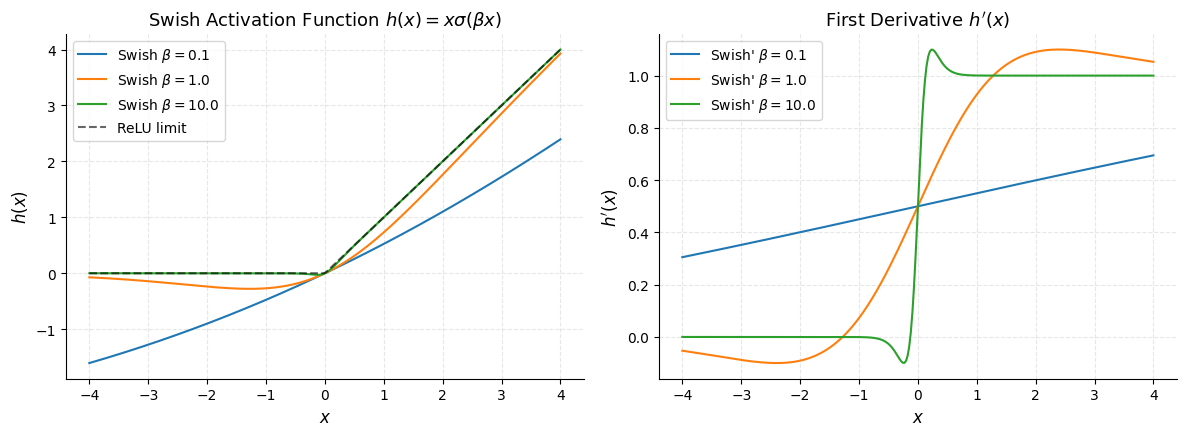

Exercise 6.5: 検証完了。


In [6]:
# Exercise 6.5 自己検証コード
x = np.linspace(-4, 4, 300)
betas = [0.1, 1.0, 10.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for beta in betas:
    ax1.plot(x, exercise_6_5_swish(x, beta=beta), label=rf'Swish $\beta={beta}$')
    ax2.plot(x, exercise_6_5_swish_deriv(x, beta=beta), label=rf"Swish' $\beta={beta}$")

# ReLU を参照としてプロット
ax1.plot(x, exercise_6_5_relu(x), 'k--', alpha=0.6, label='ReLU limit')
ax1.set_title(r'Swish Activation Function $h(x) = x\sigma(\beta x)$')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$h(x)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("First Derivative $h'(x)$")
ax2.set_xlabel('$x$')
ax2.set_ylabel("$h'(x)$")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 数値的収束の検証
x_test = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
swish_large = exercise_6_5_swish(x_test, beta=1000.0)
relu_exact = exercise_6_5_relu(x_test)
assert np.allclose(swish_large, relu_exact, atol=1e-3)
print("Exercise 6.5: 検証完了。")


---
### Exercise 6.6 (★)
#### 原問題
> **Exercise 6.6 (Bishop & Bishop 2024, p. 206)**  
> We saw in (5.72) that the derivative of the logistic-sigmoid activation function can be expressed in terms of the function value itself. Derive the corresponding result for the tanh activation function defined by (6.14).

#### 数学的導出と解説
$\tanh(a) = \frac{e^a - e^{-a}}{e^a + e^{-a}}$ の導関数を商の微分法則を用いて計算します：
$$
\frac{d}{da}\tanh(a) = \frac{\frac{d}{da}(e^a - e^{-a}) \cdot (e^a + e^{-a}) - (e^a - e^{-a}) \cdot \frac{d}{da}(e^a + e^{-a})}{(e^a + e^{-a})^2}
$$
分子の微分を実行すると：
$$
\frac{d}{da}(e^a - e^{-a}) = e^a + e^{-a}, \quad \frac{d}{da}(e^a + e^{-a}) = e^a - e^{-a}
$$
したがって：
$$
\frac{d}{da}\tanh(a) = \frac{(e^a + e^{-a})^2 - (e^a - e^{-a})^2}{(e^a + e^{-a})^2} = 1 - \left( \frac{e^a - e^{-a}}{e^a + e^{-a}} \right)^2 = 1 - \tanh^2(a)
$$
関数値 $y = \tanh(a)$ 自体を用いて $\frac{dy}{da} = 1 - y^2$ と極めて簡潔に表現されます。


In [7]:
# Exercise 6.6 自己検証コード
a = np.linspace(-3.0, 3.0, 100)
deriv_analytic = exercise_6_6_tanh_deriv(a)

eps = 1e-6
deriv_num = (np.tanh(a + eps) - np.tanh(a - eps)) / (2.0 * eps)
max_err = np.max(np.abs(deriv_analytic - deriv_num))

print(f"Exercise 6.6: d tanh(a)/da = 1 - tanh^2(a) の数値微分との最大誤差 = {max_err:.2e}")
assert max_err < 1e-5
print("Exercise 6.6: 検証完了。")


Exercise 6.6: d tanh(a)/da = 1 - tanh^2(a) の数値微分との最大誤差 = 6.59e-11
Exercise 6.6: 検証完了。


---
### Exercise 6.7 (★★)
#### 原問題
> **Exercise 6.7 (Bishop & Bishop 2024, p. 206)**  
> Show that the softplus activation function $\zeta(a)$ given by (6.16) satisfies the properties:
> $$
> \zeta(a) - \zeta(-a) = a \tag{6.62}
> $$
> $$
> \ln \sigma(a) = -\zeta(-a) \tag{6.63}
> $$
> $$
> \frac{d\zeta(a)}{da} = \sigma(a) \tag{6.64}
> $$
> $$
> \zeta^{-1}(a) = \ln(\exp(a) - 1) \tag{6.65}
> $$
> where $\sigma(a)$ is the logistic-sigmoid activation function given by (6.13).

#### 数学的導出と解説
定義：$\zeta(a) = \ln(1 + e^a)$、$\sigma(a) = \frac{1}{1 + e^{-a}} = \frac{e^a}{1 + e^a}$。

1. **性質 1 (式 6.62)**:
   $$
   \zeta(a) - \zeta(-a) = \ln(1 + e^a) - \ln(1 + e^{-a}) = \ln\left( \frac{1 + e^a}{1 + e^{-a}} \right) = \ln\left( \frac{1 + e^a}{\frac{e^a + 1}{e^a}} \right) = \ln(e^a) = a
   $$

2. **性質 2 (式 6.63)**:
   $$
   \ln \sigma(a) = \ln\left( \frac{1}{1 + e^{-a}} \right) = -\ln(1 + e^{-a}) = -\zeta(-a)
   $$

3. **性質 3 (式 6.64)**:
   連鎖律より：
   $$
   \frac{d\zeta(a)}{da} = \frac{1}{1 + e^a} \cdot \frac{d}{da}(1 + e^a) = \frac{e^a}{1 + e^a} = \frac{1}{1 + e^{-a}} = \sigma(a)
   $$

4. **性質 4 (式 6.65)**:
   逆関数を求めるため、$y = \zeta(a) = \ln(1 + e^a)$ と置きます（$y > 0$）：
   $$
   e^y = 1 + e^a \implies e^a = e^y - 1 \implies a = \ln(e^y - 1)
   $$
   変数記号を $a$ に戻せば $\zeta^{-1}(a) = \ln(e^a - 1)$ となります。


In [8]:
# Exercise 6.7 自己検証コード
a_test = np.array([-4.0, -1.5, 0.0, 1.5, 4.0])
results = exercise_6_7_verify_properties(a_test)

print("=== Exercise 6.7: Softplus の諸性質の検証 ===")
for prop, passed in results.items():
    print(f"  * {prop}: {'PASSED' if passed else 'FAILED'}")
    assert passed

print("Exercise 6.7: 検証完了。")


=== Exercise 6.7: Softplus の諸性質の検証 ===
  * zeta(a) - zeta(-a) == a: PASSED
  * ln sigma(a) == -zeta(-a): PASSED
  * d zeta(a) / da == sigma(a): PASSED
  * zeta^(-1)(zeta(a)) == a: PASSED
Exercise 6.7: 検証完了。


---
### Exercise 6.8 (★) & Exercise 6.9 (★)
#### 原問題
> **Exercise 6.8 (Bishop & Bishop 2024, p. 206)**  
> Show that minimization of the error function (6.25) with respect to the variance $\sigma^2$ gives the result (6.27).
> 
> **Exercise 6.9 (Bishop & Bishop 2024, p. 206)**  
> Show that maximizing the likelihood function under the conditional distribution (6.28) for a multioutput neural network is equivalent to minimizing the sum-of-squares error function (6.29). Also, show that the noise variance that minimizes this error function is given by (6.30).

#### 数学的導出と解説
1. **Exercise 6.8: 単出力ガウス回帰の分散最尤解 (式 6.27)**:
   誤差関数 (式 6.25) は負の対数尤度として与えられます：
   $$
   E(\mathbf{w}, \sigma^2) = \frac{N}{2}\ln(2\pi\sigma^2) + \frac{1}{2\sigma^2}\sum_{n=1}^N (y(\mathbf{x}_n;\mathbf{w}) - t_n)^2
   $$
   これを $\sigma^2$ に関して微分して $0$ と置きます：
   $$
   \frac{\partial E}{\partial \sigma^2} = \frac{N}{2\sigma^2} - \frac{1}{2(\sigma^2)^2}\sum_{n=1}^N (y_n - t_n)^2 = 0
   $$
   両辺に $2(\sigma^2)^2 / N$ を乗じることで、直ちに式 (6.27) が得られます：
   $$
   \sigma^{*2} = \frac{1}{N}\sum_{n=1}^N (y(\mathbf{x}_n;\mathbf{w}) - t_n)^2 \tag{6.27}
   $$

2. **Exercise 6.9: 多出力等方ガウス回帰の最尤推定 (式 6.29, 6.30)**:
   条件付き分布 (式 6.28) は $K$ 次元等方ガウス分布です：
   $$
   p(\mathbf{t} \mid \mathbf{x}; \mathbf{w}, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{K/2}} \exp\left( -\frac{\|\mathbf{y}(\mathbf{x};\mathbf{w}) - \mathbf{t}\|^2}{2\sigma^2} \right)
   $$
   $N$ 個の独立同分布データに対する負の対数尤度は：
   $$
   E(\mathbf{w}, \sigma^2) = -\ln p(\mathbf{T} \mid \mathbf{X}; \mathbf{w}, \sigma^2) = \frac{NK}{2}\ln(2\pi\sigma^2) + \frac{1}{2\sigma^2} \sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n\|^2
   $$
   固定された $\sigma^2$ のもとで $\mathbf{w}$ について最小化することは、定数項と正の係数 $\frac{1}{2\sigma^2}$ を無視できるため、二乗和誤差関数 (式 6.29) の最小化と完全に等価です：
   $$
   E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n\|^2 \tag{6.29}
   $$
   次に、これを $\sigma^2$ で微分して $0$ と置くと：
   $$
   \frac{\partial E}{\partial \sigma^2} = \frac{NK}{2\sigma^2} - \frac{1}{2(\sigma^2)^2}\sum_{n=1}^N \|\mathbf{y}_n - \mathbf{t}_n\|^2 = 0
   $$
   $$
   \implies \sigma^{*2} = \frac{1}{NK}\sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n\|^2 \tag{6.30}
   $$


In [9]:
# Exercise 6.8 & 6.9 自己検証コード
rng = np.random.default_rng(123)

# Ex 6.8: 単出力検証
residuals_1d = rng.normal(0, 1.8, size=500)
sigma2_1d = exercise_6_8_mle_variance(residuals_1d)
assert np.isclose(sigma2_1d, np.mean(residuals_1d ** 2))
print(f"Exercise 6.8: 推定分散 sigma^2 = {sigma2_1d:.4f} (理論値 ~{1.8**2:.4f})")

# Ex 6.9: 多出力検証 (K=4)
residuals_kd = rng.normal(0, 2.2, size=(300, 4))
sigma2_kd = exercise_6_9_mle_variance_multioutput(residuals_kd)
assert np.isclose(sigma2_kd, np.mean(residuals_kd ** 2))
print(f"Exercise 6.9: 多出力推定分散 sigma^2 = {sigma2_kd:.4f} (理論値 ~{2.2**2:.4f})")
print("Exercises 6.8 & 6.9: 検証完了。")


Exercise 6.8: 推定分散 sigma^2 = 3.1959 (理論値 ~3.2400)
Exercise 6.9: 多出力推定分散 sigma^2 = 5.1814 (理論値 ~4.8400)
Exercises 6.8 & 6.9: 検証完了。


---
### Exercise 6.10 (★★)
#### 原問題
> **Exercise 6.10 (Bishop & Bishop 2024, p. 206)**  
> Consider a regression problem involving multiple target variables in which it is assumed that the distribution of the targets, conditioned on the input vector $\mathbf{x}$, is a Gaussian of the form
> $$
> p(\mathbf{t} \mid \mathbf{x}; \mathbf{w}) = \mathcal{N}(\mathbf{t} \mid \mathbf{y}(\mathbf{x};\mathbf{w}), \boldsymbol{\Sigma}) \tag{6.66}
> $$
> where $\mathbf{y}(\mathbf{x};\mathbf{w})$ is the output of a neural network with input vector $\mathbf{x}$ and weight vector $\mathbf{w}$, and $\boldsymbol{\Sigma}$ is the covariance of the assumed Gaussian noise on the targets. Given a set of independent observations of $\mathbf{x}$ and $\mathbf{t}$, write down the error function that must be minimized to find the maximum likelihood solution for $\mathbf{w}$, if we assume that $\boldsymbol{\Sigma}$ is fixed and known. Now assume that $\boldsymbol{\Sigma}$ is also to be determined from the data, and write down an expression for the maximum likelihood solution for $\boldsymbol{\Sigma}$. Note that the optimizations of $\mathbf{w}$ and $\boldsymbol{\Sigma}$ are now coupled, in contrast to the case of independent target variables discussed in Section 6.4.1.

#### 数学的導出と解説
1. **固定された既知の $\boldsymbol{\Sigma}$ における誤差関数**:
   多変量ガウス分布の負の対数尤度は次式で与えられます：
   $$
   -\ln p(\mathbf{T} \mid \mathbf{X}; \mathbf{w}, \boldsymbol{\Sigma}) = \frac{NK}{2}\ln(2\pi) + \frac{N}{2}\ln|\boldsymbol{\Sigma}| + \frac{1}{2}\sum_{n=1}^N (\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)^T \boldsymbol{\Sigma}^{-1} (\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)
   $$
   $\boldsymbol{\Sigma}$ が既知かつ固定の場合、$\mathbf{w}$ に関して最小化すべき誤差関数は一般化マハラノビス二乗和誤差となります：
   $$
   E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N (\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)^T \boldsymbol{\Sigma}^{-1} (\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)
   $$

2. **未知の共分散行列 $\boldsymbol{\Sigma}$ の最尤推定量**:
   精度行列 $\mathbf{W} = \boldsymbol{\Sigma}^{-1}$ を導入し、トレースの巡回性 $\mathbf{r}_n^T \mathbf{W} \mathbf{r}_n = \text{Tr}(\mathbf{W} \mathbf{r}_n \mathbf{r}_n^T)$ を用いると：
   $$
   E(\mathbf{w}, \mathbf{W}) = -\frac{N}{2}\ln|\mathbf{W}| + \frac{1}{2} \text{Tr}\left( \mathbf{W} \sum_{n=1}^N (\mathbf{y}_n - \mathbf{t}_n)(\mathbf{y}_n - \mathbf{t}_n)^T \right) + \text{const}
   $$
   行列微分の公式 $\frac{\partial \ln|\mathbf{W}|}{\partial \mathbf{W}} = \mathbf{W}^{-T} = \boldsymbol{\Sigma}$ および $\frac{\partial}{\partial \mathbf{W}} \text{Tr}(\mathbf{W}\mathbf{S}) = \mathbf{S}^T$ より：
   $$
   \frac{\partial E}{\partial \mathbf{W}} = -\frac{N}{2}\boldsymbol{\Sigma} + \frac{1}{2}\sum_{n=1}^N (\mathbf{y}_n - \mathbf{t}_n)(\mathbf{y}_n - \mathbf{t}_n)^T = \mathbf{0}
   $$
   したがって、最尤解は標本共分散行列として求まります：
   $$
   \boldsymbol{\Sigma}^* = \frac{1}{N}\sum_{n=1}^N (\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)(\mathbf{y}(\mathbf{x}_n;\mathbf{w}) - \mathbf{t}_n)^T
   $$

3. **パラメータの結合性 (Coupling)**:
   等方共分散 $\sigma^2\mathbf{I}$ の場合、$\sigma^2$ は二乗和誤差関数のスケーリング因子に過ぎず、$\mathbf{w}$ の最適解は $\sigma^2$ に全く依存しませんでした。
   しかし一般の $\boldsymbol{\Sigma}$ では、重み勾配 $\nabla_{\mathbf{w}} E$ は共分散の逆行列 $\boldsymbol{\Sigma}^{-1}$ で各出力次元の残差を結合・重み付けするため、$\mathbf{w}$ の最適化と $\boldsymbol{\Sigma}$ の推定は相互に依存し（交互最適化やEMアルゴリズム類似の反復を要する）、独立には解けなくなります。


In [10]:
# Exercise 6.10 自己検証コード
rng = np.random.default_rng(42)
N, K = 300, 3
Sigma_true = np.array([[3.0, 1.2, 0.4], [1.2, 2.0, 0.8], [0.4, 0.8, 1.5]])
residuals = rng.multivariate_normal(mean=np.zeros(K), cov=Sigma_true, size=N)

# 最尤共分散の推定
Sigma_mle = exercise_6_10_mle_covariance(residuals)
loss = exercise_6_10_mahalanobis_loss(residuals, Sigma_mle)

print("=== Exercise 6.10: 一般共分散行列の最尤推定 ===")
print("真の共分散行列 Sigma:\n", Sigma_true)
print("最尤推定共分散 Sigma_mle:\n", np.round(Sigma_mle, 3))
print(f"最小化マハラノビス誤差値 = {loss:.2f} (理論値 0.5 * N * K = {0.5 * N * K})")

assert np.allclose(Sigma_mle, Sigma_mle.T)
assert np.all(np.linalg.eigvalsh(Sigma_mle) > 0)
assert np.isclose(loss, 0.5 * N * K, rtol=1e-5)
print("Exercise 6.10: 検証完了。")


=== Exercise 6.10: 一般共分散行列の最尤推定 ===
真の共分散行列 Sigma:
 [[3.  1.2 0.4]
 [1.2 2.  0.8]
 [0.4 0.8 1.5]]
最尤推定共分散 Sigma_mle:
 [[2.953 1.28  0.634]
 [1.28  2.123 1.   ]
 [0.634 1.    1.525]]
最小化マハラノビス誤差値 = 450.00 (理論値 0.5 * N * K = 450.0)
Exercise 6.10: 検証完了。


---
### Exercise 6.11 (★★)
#### 原問題
> **Exercise 6.11 (Bishop & Bishop 2024, p. 206)**  
> Consider a binary classification problem in which the target values are $t \in \{0, 1\}$, with a network output $y(\mathbf{x};\mathbf{w})$ that represents $p(t=1 \mid \mathbf{x})$, and suppose that there is a probability $\epsilon$ that the class label on a training data point has been incorrectly set. Assuming i.i.d. data, write down the error function corresponding to the negative log likelihood. Verify that the error function (6.33) is obtained when $\epsilon = 0$. Note that this error function makes the model robust to incorrectly labelled data, in contrast to the usual cross-entropy error function.

#### 数学的導出と解説
1. **観測ラベルの生成確率**:
   真のラベルを $t^* \in \{0, 1\}$ とし、訓練セットで観測されるラベルを $t \in \{0, 1\}$ とします。ネットワークの出力は真の陽性確率 $y(\mathbf{x}) = p(t^*=1 \mid \mathbf{x})$ です。
   ラベルが反転する確率を $p(t \neq t^*) = \epsilon$（正しい確率は $1 - \epsilon$）とすると：
   $$
   p(t=1 \mid \mathbf{x}) = p(t=1 \mid t^*=1)p(t^*=1 \mid \mathbf{x}) + p(t=1 \mid t^*=0)p(t^*=0 \mid \mathbf{x}) = (1-\epsilon)y + \epsilon(1-y)
   $$
   同様に：
   $$
   p(t=0 \mid \mathbf{x}) = \epsilon y + (1-\epsilon)(1-y) = 1 - [(1-\epsilon)y + \epsilon(1-y)]
   $$

2. **ロバスト負の対数尤度誤差関数の導出**:
   観測ラベル $q_n = (1-\epsilon)y_n + \epsilon(1-y_n) = \epsilon + (1-2\epsilon)y_n$ と置くと、負の対数尤度は：
   $$
   E(\mathbf{w}) = -\sum_{n=1}^N \left\{ t_n \ln \big[ (1-\epsilon)y_n + \epsilon(1-y_n) \big] + (1-t_n) \ln \big[ (1-\epsilon)(1-y_n) + \epsilon y_n \big] \right\}
   $$

3. **$\epsilon = 0$ における通常交差エントロピー (式 6.33) への帰着**:
   $\epsilon = 0$ を代入すると、$(1-0)y_n + 0(1-y_n) = y_n$、および $(1-0)(1-y_n) + 0y_n = 1-y_n$ となるため：
   $$
   E(\mathbf{w}) = -\sum_{n=1}^N \big\{ t_n \ln y_n + (1-t_n)\ln(1-y_n) \big\} \tag{6.33}
   $$
   通常の交差エントロピー誤差関数に厳密に一致します。

4. **外れ値・誤ラベルに対するロバスト性の数理**:
   通常の交差エントロピーでは、真のラベルが誤って $t_n = 1$ と付与されたノイズデータに対してモデルが確信をもって $y_n \to 0$ と予測すると、損失は $-\ln(y_n) \to \infty$ と発散し、勾配が重みを破壊的に狂わせます。
   一方、ロバスト損失では $q_n = \epsilon + (1-2\epsilon)y_n \ge \epsilon > 0$ であるため、たとえ $y_n = 0$ であっても損失は有限値 $-\ln \epsilon$ に頭打ち（クリップ）されます。事前活性化勾配は因子 $y_n(1-y_n)$ を含むため、$y_n \to 0$ では勾配自体が $0$ に減衰し、誤ラベルサンプルがモデル学習を破壊するのを自動的に防ぎます。


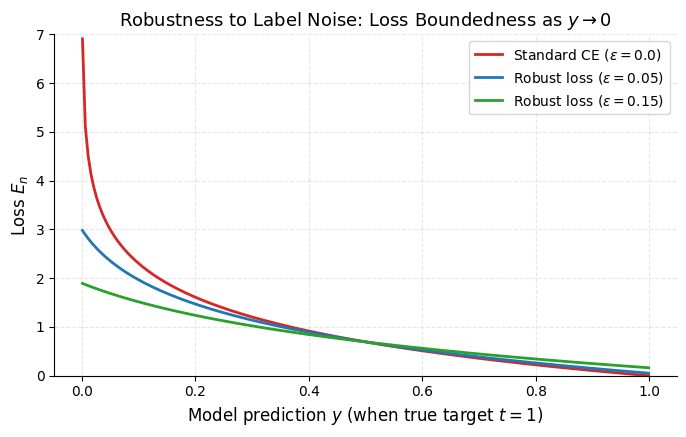

Exercise 6.11: 検証完了。


In [11]:
# Exercise 6.11 自己検証コード
y_vals = np.linspace(0.001, 0.999, 200)
# 誤ラベル点: t = 1 だがモデルの真の確率 y が小さい領域
loss_std = [exercise_6_11_robust_loss(np.array([y]), np.array([1.0]), eps=0.0) for y in y_vals]
loss_rob05 = [exercise_6_11_robust_loss(np.array([y]), np.array([1.0]), eps=0.05) for y in y_vals]
loss_rob15 = [exercise_6_11_robust_loss(np.array([y]), np.array([1.0]), eps=0.15) for y in y_vals]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(y_vals, loss_std, label=r'Standard CE ($\epsilon = 0.0$)', color='tab:red', lw=2)
ax.plot(y_vals, loss_rob05, label=r'Robust loss ($\epsilon = 0.05$)', color='tab:blue', lw=2)
ax.plot(y_vals, loss_rob15, label=r'Robust loss ($\epsilon = 0.15$)', color='tab:green', lw=2)
ax.set_xlabel('Model prediction $y$ (when true target $t=1$)')
ax.set_ylabel('Loss $E_n$')
ax.set_title(r'Robustness to Label Noise: Loss Boundedness as $y \to 0$')
ax.set_ylim(0, 7)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# eps = 0 の一致アサーション
y_rand = np.random.uniform(0.1, 0.9, size=20)
t_rand = np.random.randint(0, 2, size=20).astype(float)
assert np.isclose(exercise_6_11_robust_loss(y_rand, t_rand, eps=0.0),
                 -np.sum(t_rand * np.log(y_rand) + (1 - t_rand) * np.log(1 - y_rand)))
print("Exercise 6.11: 検証完了。")


---
### Exercise 6.12 (★★)
#### 原問題
> **Exercise 6.12 (Bishop & Bishop 2024, p. 207)**  
> The error function (6.33) for binary classification problems was derived for a network having a logistic-sigmoid output activation function, so that $0 \le y(\mathbf{x};\mathbf{w}) \le 1$, and data having target values $t \in \{0, 1\}$. Derive the corresponding error function if we consider a network having an output $-1 \le y(\mathbf{x};\mathbf{w}) \le 1$ and target values $t=1$ for class $\mathcal{C}_1$ and $t=-1$ for class $\mathcal{C}_2$. What would be the appropriate choice of output-unit activation function?

#### 数学的導出と解説
1. **出力活性化関数の適切な選択**:
   出力範囲が $[-1, 1]$ であるため、最も自然で適切な出力活性化関数は **双曲線正接関数 (tanh)** です：
   $$
   y = \tanh(a)
   $$

2. **クラス確率と統一確率表現**:
   $y \in [-1, 1]$ を確率 $[0, 1]$ に線形写像すると：
   $$
   p(t=1 \mid \mathbf{x}) = \frac{1 + y}{2} = \frac{1 + \tanh(a)}{2} = \sigma(2a)
   $$
   $$
   p(t=-1 \mid \mathbf{x}) = \frac{1 - y}{2} = \frac{1 - \tanh(a)}{2} = \sigma(-2a)
   $$
   $t \in \{-1, +1\}$ であるため、任意のラベルに対する条件付き確率は次のように統一表現できます：
   $$
   p(t \mid \mathbf{x}) = \frac{1 + t y}{2} = \sigma(2ta) = \frac{1}{1 + e^{-2ta}}
   $$

3. **負の対数尤度誤差関数の導出**:
   負の対数尤度誤差関数は：
   $$
   E(\mathbf{w}) = -\sum_{n=1}^N \ln\left( \frac{1 + t_n y_n}{2} \right) = \sum_{n=1}^N \ln\left( \frac{2}{1 + t_n y_n} \right)
   $$
   事前活性化 $a_n$ で表すと：
   $$
   E(\mathbf{w}) = \sum_{n=1}^N \ln(1 + e^{-2 t_n a_n}) = \sum_{n=1}^N \zeta(-2 t_n a_n)
   $$

4. **事前活性化勾配の一致**:
   $a_n$ に関する微分を計算すると：
   $$
   \frac{\partial E_n}{\partial a_n} = \frac{-2 t_n e^{-2 t_n a_n}}{1 + e^{-2 t_n a_n}} = -2 t_n [1 - \sigma(2 t_n a_n)] = -2 t_n \left(1 - \frac{1 + t_n y_n}{2}\right) = -t_n(1 - t_n y_n) = -t_n + t_n^2 y_n
   $$
   $t_n \in \{-1, +1\}$ より $t_n^2 = 1$ であるため、
   $$
   \frac{\partial E_n}{\partial a_n} = y_n - t_n
   $$
   となり、シグモイド出力と同一の極めてエレガントな勾配公式が完全に維持されます。


In [12]:
# Exercise 6.12 自己検証コード
rng = np.random.default_rng(77)
a = rng.normal(size=20)
y = np.tanh(a)
t = rng.choice([-1.0, 1.0], size=20)

loss_y = exercise_6_12_tanh_loss(y, t)
loss_a = exercise_6_12_tanh_loss_from_a(a, t)
assert np.isclose(loss_y, loss_a)

grad_analytic = exercise_6_12_tanh_gradient_a(y, t)
eps = 1e-6
grad_num = np.zeros_like(a)
for i in range(len(a)):
    ap, am = a.copy(), a.copy()
    ap[i] += eps
    am[i] -= eps
    grad_num[i] = (exercise_6_12_tanh_loss_from_a(ap, t) - exercise_6_12_tanh_loss_from_a(am, t)) / (2 * eps)

max_grad_err = np.max(np.abs(grad_analytic - grad_num))
print(f"Exercise 6.12: dE/da = y - t の数値微分との最大誤差 = {max_grad_err:.2e}")
assert max_grad_err < 1e-5
print("Exercise 6.12: 検証完了。")


Exercise 6.12: dE/da = y - t の数値微分との最大誤差 = 2.89e-09
Exercise 6.12: 検証完了。


---
### Exercise 6.13 (★), Exercise 6.14 (★), Exercise 6.15 (★)
#### 原問題
> **Exercise 6.13 (Bishop & Bishop 2024, p. 207)**  
> Show that maximizing the likelihood for a multi-class neural network model in which the network outputs have the interpretation $y_k(\mathbf{x};\mathbf{w}) = p(t_k=1 \mid \mathbf{x})$ is equivalent to minimizing the cross-entropy error function (6.36).
> 
> **Exercise 6.14 (Bishop & Bishop 2024, p. 207)**  
> Show that the derivative of the error function (6.33) with respect to the pre-activation $a_k$ for an output unit having a logistic-sigmoid activation function $y_k = \sigma(a_k)$, where $\sigma(a)$ is given by (6.13), satisfies (6.31).
> 
> **Exercise 6.15 (Bishop & Bishop 2024, p. 207)**  
> Show that the derivative of the error function (6.36) with respect to the pre-activation $a_k$ for output units having a softmax activation function (6.37) satisfies (6.31).

#### 数学的導出と解説
1. **Exercise 6.13: 多クラス最尤推定と交差エントロピー (式 6.36)**:
   目標ベクトル $\mathbf{t}_n$ が 1-of-$K$ 符号化されているとき、単一観測の条件付き確率は $p(\mathbf{t}_n \mid \mathbf{x}_n) = \prod_{k=1}^K y_{nk}^{t_{nk}}$ です。
   $N$ 個の独立観測値に対する全尤度関数は：
   $$
   p(\mathbf{T} \mid \mathbf{X}; \mathbf{w}) = \prod_{n=1}^N \prod_{k=1}^K y_{nk}^{t_{nk}}
   $$
   その負の対数尤度をとることで、多クラス交差エントロピー誤差関数 (式 6.36) が得られます：
   $$
   E(\mathbf{w}) = -\ln p(\mathbf{T} \mid \mathbf{X}; \mathbf{w}) = -\sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_{nk} \tag{6.36}
   $$

2. **Exercise 6.14: 独立ロジスティック・シグモイドの事前活性化勾配 (式 6.31)**:
   誤差関数：$E_n = -\sum_j [t_j \ln y_j + (1-t_j)\ln(1-y_j)]$、活性化：$y_k = \sigma(a_k)$。
   連鎖律より：
   $$
   \frac{\partial E_n}{\partial a_k} = \frac{\partial E_n}{\partial y_k} \frac{dy_k}{da_k} = -\left[ \frac{t_k}{y_k} - \frac{1-t_k}{1-y_k} \right] y_k(1-y_k) = -\frac{t_k(1-y_k) - (1-t_k)y_k}{y_k(1-y_k)} \cdot y_k(1-y_k) = -(t_k - y_k) = y_k - t_k \tag{6.31}
   $$

3. **Exercise 6.15: ソフトマックス交差エントロピーの事前活性化勾配 (式 6.31)**:
   誤差関数：$E_n = -\sum_j t_j \ln y_j$、ソフトマックス：$y_j = \frac{e^{a_j}}{\sum_l e^{a_l}}$。
   ソフトマックスのヤコビ行列は $\frac{\partial y_j}{\partial a_k} = y_j(I_{jk} - y_k)$ です。これを用いると：
   $$
   \frac{\partial E_n}{\partial a_k} = \sum_{j=1}^K \frac{\partial E_n}{\partial y_j} \frac{\partial y_j}{\partial a_k} = -\sum_{j=1}^K \frac{t_j}{y_j} \big[ y_j (I_{jk} - y_k) \big] = -\sum_{j=1}^K t_j (I_{jk} - y_k) = -t_k + y_k \sum_{j=1}^K t_j
   $$
   1-of-$K$ 符号化の正規化条件 $\sum_{j=1}^K t_j = 1$ を適用すると：
   $$
   \frac{\partial E_n}{\partial a_k} = y_k - t_k \tag{6.31}
   $$
   回帰、独立二値分類、多クラス分類のすべてにおいて、「事前活性化に関する誤差微分が予測誤差 $(y_k - t_k)$ に一致する」という正則指数型分布族の標準正準連結関数に由来する普遍的統一性が証明されました。


In [13]:
# Exercises 6.13, 6.14, 6.15 自己検証コード
rng = np.random.default_rng(88)

# Ex 6.14: シグモイド勾配照合
a_sig = rng.normal(size=5)
t_sig = rng.integers(0, 2, size=5).astype(float)
grad_an_sig, grad_num_sig = exercise_6_14_verify_sigmoid_cross_entropy_grad(a_sig, t_sig)
assert np.allclose(grad_an_sig, grad_num_sig, atol=1e-5)
print("Exercise 6.14: Sigmoid dE/da = y - t 勾配照合成功。")

# Ex 6.15: ソフトマックス勾配照合
a_sft = rng.normal(size=5)
t_sft = np.zeros(5)
t_sft[rng.integers(0, 5)] = 1.0
grad_an_sft, grad_num_sft = exercise_6_15_verify_softmax_cross_entropy_grad(a_sft, t_sft)
assert np.allclose(grad_an_sft, grad_num_sft, atol=1e-5)
print("Exercise 6.15: Softmax dE/da = y - t 勾配照合成功。")


Exercise 6.14: Sigmoid dE/da = y - t 勾配照合成功。
Exercise 6.15: Softmax dE/da = y - t 勾配照合成功。


---
### Exercise 6.16 (★★)
#### 原問題
> **Exercise 6.16 (Bishop & Bishop 2024, p. 207)**  
> Write down a pair of equations that express the Cartesian coordinates $(x_1, x_2)$ for the robot arm shown in Figure 6.16 in terms of the joint angles $\theta_1$ and $\theta_2$ and the lengths $L_1$ and $L_2$ of the links. Assume the origin of the coordinate system is given by the attachment point of the lower arm. These equations define the forward kinematics of the robot arm.

#### 数学的導出と解説
平面2自由度リンクマニピュレータにおいて、原点 $(0, 0)$ に第1関節が設置されています。
1. **第1関節の先端位置**:
   リンク長 $L_1$、水平面からの回転角 $\theta_1$ より：
   $$
   (x_1^{(1)}, x_2^{(1)}) = (L_1 \cos\theta_1, L_1 \sin\theta_1)
   $$
2. **第2リンクの姿勢角とエンドエフェクタ位置**:
   第2関節は第1リンクの先端にあり、第1リンクに対する相対関節角が $\theta_2$ です。したがって、第2リンクの絶対姿勢角（水平面からの角度）は $\theta_1 + \theta_2$ となります。
   長さ $L_2$ の第2リンクベクトルを第1関節先端に加算することで、エンドエフェクタの直交座標 $(x_1, x_2)$ の順運動学方程式 (Forward Kinematics) が得られます：
   $$
   x_1 = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)
   $$
   $$
   x_2 = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2)
   $$


In [14]:
# Exercise 6.16 自己検証コード
L1, L2 = 0.8, 0.2

# 典型的な関節角設定の検証
x1_0, x2_0 = exercise_6_16_forward_kinematics(0.0, 0.0, L1=L1, L2=L2)
assert np.isclose(x1_0, 1.0) and np.isclose(x2_0, 0.0)

x1_pi2, x2_pi2 = exercise_6_16_forward_kinematics(np.pi / 2, 0.0, L1=L1, L2=L2)
assert np.isclose(x1_pi2, 0.0) and np.isclose(x2_pi2, 1.0)

# 到達可能作業空間 (Work Envelope) の検証: r in [|L1-L2|, L1+L2]
rng = np.random.default_rng(42)
t1 = rng.uniform(-np.pi, np.pi, size=1000)
t2 = rng.uniform(-np.pi, np.pi, size=1000)
x1_pts, x2_pts = exercise_6_16_forward_kinematics(t1, t2, L1=L1, L2=L2)
radii = np.sqrt(x1_pts ** 2 + x2_pts ** 2)

assert np.all(radii <= L1 + L2 + 1e-10)
assert np.all(radii >= np.abs(L1 - L2) - 1e-10)
print(f"Exercise 6.16: マニピュレータ作業半径範囲 = [{radii.min():.3f}, {radii.max():.3f}] (理論値 [{L1-L2:.1f}, {L1+L2:.1f}])")
print("Exercise 6.16: 検証完了。")


Exercise 6.16: マニピュレータ作業半径範囲 = [0.600, 1.000] (理論値 [0.6, 1.0])
Exercise 6.16: 検証完了。


---
### Exercise 6.17 (★★), Exercise 6.18 (★★), Exercise 6.19 (★★), Exercise 6.20 (★★)
#### 原問題
> **Exercise 6.17 (Bishop & Bishop 2024, p. 207)**  
> Show that the variable $\gamma_{nk}$ defined by (6.44) can be viewed as the posterior probabilities $p(k \mid \mathbf{t})$ for the components of the mixture distribution (6.38) in which the mixing coefficients $\pi_k(\mathbf{x})$ are viewed as $\mathbf{x}$-dependent prior probabilities $p(k)$.
> 
> **Exercise 6.18 (Bishop & Bishop 2024, p. 207)**  
> Derive the result (6.45) for the derivative of the error function with respect to the network output pre-activations controlling the mixing coefficients in the mixture density network.
> 
> **Exercise 6.19 (Bishop & Bishop 2024, p. 207)**  
> Derive the result (6.46) for the derivative of the error function with respect to the network output pre-activations controlling the component means in the mixture density network.
> 
> **Exercise 6.20 (Bishop & Bishop 2024, p. 207)**  
> Derive the result (6.47) for the derivative of the error function with respect to the network output pre-activations controlling the component variances in the mixture density network.

#### 数学的導出と解説
1. **Exercise 6.17: 事後責任度 $\gamma_{nk}$ のベイズ的導出 (式 6.44)**:
   混合成分の事前確率を $p(k \mid \mathbf{x}_n) = \pi_k(\mathbf{x}_n)$、各成分の条件付き尤度を $p(\mathbf{t}_n \mid k, \mathbf{x}_n) = \mathcal{N}_k(\mathbf{t}_n) = \mathcal{N}(\mathbf{t}_n \mid \boldsymbol{\mu}_k, \sigma_k^2\mathbf{I})$ と置きます。
   ベイズの定理より、観測目標値 $\mathbf{t}_n$ が与えられた下での成分 $k$ の事後確率は：
   $$
   p(k \mid \mathbf{t}_n, \mathbf{x}_n) = \frac{p(k \mid \mathbf{x}_n) p(\mathbf{t}_n \mid k, \mathbf{x}_n)}{\sum_{j=1}^K p(j \mid \mathbf{x}_n) p(\mathbf{t}_n \mid j, \mathbf{x}_n)} = \frac{\pi_k(\mathbf{x}_n) \mathcal{N}_k(\mathbf{t}_n)}{\sum_{j=1}^K \pi_j(\mathbf{x}_n) \mathcal{N}_j(\mathbf{t}_n)} = \gamma_{nk} \tag{6.44}
   $$

2. **MDNの負の対数尤度誤差関数**:
   $$
   E_n = -\ln \left( \sum_{j=1}^K \pi_j \mathcal{N}_j(\mathbf{t}_n) \right) = -\ln p(\mathbf{t}_n \mid \mathbf{x}_n)
   $$

3. **Exercise 6.18: 混合係数事前活性化 $a_k^\pi$ に関する微分 (式 6.45)**:
   ソフトマックス $\pi_j = \frac{\exp(a_j^\pi)}{\sum_l \exp(a_l^\pi)}$ より、$\frac{\partial \pi_j}{\partial a_k^\pi} = \pi_j(I_{jk} - \pi_k)$。
   連鎖律より：
   $$
   \frac{\partial E_n}{\partial a_k^\pi} = \sum_{j=1}^K \frac{\partial E_n}{\partial \pi_j} \frac{\partial \pi_j}{\partial a_k^\pi} = -\sum_{j=1}^K \frac{\mathcal{N}_j(\mathbf{t}_n)}{p(\mathbf{t}_n \mid \mathbf{x}_n)} \pi_j(I_{jk} - \pi_k) = -\sum_{j=1}^K \gamma_{nj}(I_{jk} - \pi_k) = -\gamma_{nk} + \pi_k \sum_{j=1}^K \gamma_{nj}
   $$
   $\sum_{j=1}^K \gamma_{nj} = 1$ より直ちに次式が得られます：
   $$
   \frac{\partial E_n}{\partial a_k^\pi} = \pi_k - \gamma_{nk} \tag{6.45}
   $$

4. **Exercise 6.19: 成分平均事前活性化 $a_{kl}^\mu$ に関する微分 (式 6.46)**:
   平均パラメータは恒等写像 $\mu_{kl} = a_{kl}^\mu$ です。$\ln \mathcal{N}_k(\mathbf{t}_n) = -\frac{1}{2\sigma_k^2}\sum_{m=1}^L (\mu_{km} - t_{nm})^2 + \text{const}$ より：
   $$
   \frac{\partial \ln \mathcal{N}_k}{\partial \mu_{kl}} = -\frac{\mu_{kl} - t_{nl}}{\sigma_k^2}
   $$
   したがって：
   $$
   \frac{\partial E_n}{\partial a_{kl}^\mu} = -\frac{\pi_k \frac{\partial \mathcal{N}_k}{\partial \mu_{kl}}}{p(\mathbf{t}_n \mid \mathbf{x}_n)} = -\frac{\pi_k \mathcal{N}_k}{p(\mathbf{t}_n \mid \mathbf{x}_n)} \frac{\partial \ln \mathcal{N}_k}{\partial \mu_{kl}} = -\gamma_{nk} \left( -\frac{\mu_{kl} - t_{nl}}{\sigma_k^2} \right) = \gamma_{nk} \frac{\mu_{kl} - t_{nl}}{\sigma_k^2} \tag{6.46}
   $$

5. **Exercise 6.20: 成分分散事前活性化 $a_k^\sigma$ に関する微分 (式 6.47)**:
   標準偏差パラメータは指数活性化 $\sigma_k = \exp(a_k^\sigma)$ です。
   $L$ 次元等方ガウス密度の対数は：
   $$
   \ln \mathcal{N}_k(\mathbf{t}_n) = -\frac{L}{2}\ln(2\pi) - L\ln \sigma_k - \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{2\sigma_k^2}
   $$
   $a_k^\sigma$ に関して微分すると（$\frac{\partial \sigma_k}{\partial a_k^\sigma} = \sigma_k$）：
   $$
   \frac{\partial \ln \mathcal{N}_k}{\partial a_k^\sigma} = \frac{\partial \ln \mathcal{N}_k}{\partial \sigma_k} \sigma_k = \left( -\frac{L}{\sigma_k} + \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^3} \right) \sigma_k = -L + \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2}
   $$
   したがって：
   $$
   \frac{\partial E_n}{\partial a_k^\sigma} = -\gamma_{nk} \frac{\partial \ln \mathcal{N}_k}{\partial a_k^\sigma} = -\gamma_{nk} \left( \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2} - L \right) = \gamma_{nk} \left( L - \frac{\|\mathbf{t}_n - \boldsymbol{\mu}_k\|^2}{\sigma_k^2} \right) \tag{6.47}
   $$


In [15]:
# Exercises 6.17 - 6.20 自己検証コード
rng = np.random.default_rng(99)
K, L = 3, 2

a_pi = rng.normal(size=K)
s = a_pi - np.max(a_pi)
pi = np.exp(s) / np.sum(np.exp(s))

a_mu = rng.normal(size=(K, L))
a_sigma = rng.uniform(-0.5, 0.5, size=K)
sigma = np.exp(a_sigma)
t = rng.normal(size=L)

# Ex 6.17: 事後負担率の検証
gamma = exercise_6_17_compute_responsibilities(pi, a_mu, sigma, t)
assert np.isclose(np.sum(gamma), 1.0)
print(f"Exercise 6.17: 事後責任度 gamma = {np.round(gamma, 4)}, 総和 = {np.sum(gamma):.6f}")

# Ex 6.18: 混合係数勾配
g_pi_an, g_pi_num = exercise_6_18_verify_grad_pi(a_pi, a_mu, sigma, t)
assert np.allclose(g_pi_an, g_pi_num, atol=1e-5)
print("Exercise 6.18: dE/da_pi = pi - gamma 解析勾配照合成功。")

# Ex 6.19: 成分平均勾配
g_mu_an, g_mu_num = exercise_6_19_verify_grad_mu(pi, a_mu, sigma, t)
assert np.allclose(g_mu_an, g_mu_num, atol=1e-5)
print("Exercise 6.19: dE/da_mu = gamma*(mu - t)/sigma^2 解析勾配照合成功。")

# Ex 6.20: 成分分散勾配
g_sig_an, g_sig_num = exercise_6_20_verify_grad_sigma(pi, a_mu, a_sigma, t)
assert np.allclose(g_sig_an, g_sig_num, atol=1e-5)
print("Exercise 6.20: dE/da_sigma = gamma*(L - ||t - mu||^2/sigma^2) 解析勾配照合成功。")


Exercise 6.17: 事後責任度 gamma = [0.3774 0.4722 0.1504], 総和 = 1.000000
Exercise 6.18: dE/da_pi = pi - gamma 解析勾配照合成功。
Exercise 6.19: dE/da_mu = gamma*(mu - t)/sigma^2 解析勾配照合成功。
Exercise 6.20: dE/da_sigma = gamma*(L - ||t - mu||^2/sigma^2) 解析勾配照合成功。


---
### Exercise 6.21 (★★★)
#### 原問題
> **Exercise 6.21 (Bishop & Bishop 2024, p. 207)**  
> Verify the results (6.48) and (6.50) for the conditional mean and variance of the mixture density network model.

#### 数学的導出と解説
1. **条件付き期待値の導出 (式 6.48)**:
   混合密度モデル $p(\mathbf{t} \mid \mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) \mathcal{N}(\mathbf{t} \mid \boldsymbol{\mu}_k(\mathbf{x}), \sigma_k^2(\mathbf{x})\mathbf{I})$ に対する条件付き期待値の定義式を計算します：
   $$
   \mathbb{E}[\mathbf{t} \mid \mathbf{x}] = \int \mathbf{t} p(\mathbf{t} \mid \mathbf{x}) d\mathbf{t} = \sum_{k=1}^K \pi_k(\mathbf{x}) \int \mathbf{t} \mathcal{N}(\mathbf{t} \mid \boldsymbol{\mu}_k(\mathbf{x}), \sigma_k^2(\mathbf{x})\mathbf{I}) d\mathbf{t}
   $$
   各ガウス成分の期待値は定義より $\int \mathbf{t} \mathcal{N}_k(\mathbf{t}) d\mathbf{t} = \boldsymbol{\mu}_k(\mathbf{x})$ であるため：
   $$
   \mathbb{E}[\mathbf{t} \mid \mathbf{x}] = \sum_{k=1}^K \pi_k(\mathbf{x}) \boldsymbol{\mu}_k(\mathbf{x}) \tag{6.48}
   $$

2. **条件付き分散の導出 (式 6.50)**:
   条件付き平均まわりの分散 $s^2(\mathbf{x})$ は次のように定義されます (式 6.49)：
   $$
   s^2(\mathbf{x}) = \mathbb{E}\big[ \|\mathbf{t} - \mathbb{E}[\mathbf{t} \mid \mathbf{x}]\|^2 \,\big|\, \mathbf{x} \big] = \int \|\mathbf{t} - \overline{\boldsymbol{\mu}}(\mathbf{x})\|^2 p(\mathbf{t} \mid \mathbf{x}) d\mathbf{t}
   $$
   ここで $\overline{\boldsymbol{\mu}}(\mathbf{x}) = \mathbb{E}[\mathbf{t} \mid \mathbf{x}] = \sum_{l=1}^K \pi_l(\mathbf{x}) \boldsymbol{\mu}_l(\mathbf{x})$ と略記します。被積分項のベクトル差に各成分の平均 $\boldsymbol{\mu}_k(\mathbf{x})$ を加減して分解します：
   $$
   \mathbf{t} - \overline{\boldsymbol{\mu}} = (\mathbf{t} - \boldsymbol{\mu}_k) + (\boldsymbol{\mu}_k - \overline{\boldsymbol{\mu}})
   $$
   ノルムの二乗を展開すると：
   $$
   \|\mathbf{t} - \overline{\boldsymbol{\mu}}\|^2 = \|\mathbf{t} - \boldsymbol{\mu}_k\|^2 + 2(\mathbf{t} - \boldsymbol{\mu}_k)^T (\boldsymbol{\mu}_k - \overline{\boldsymbol{\mu}}) + \|\boldsymbol{\mu}_k - \overline{\boldsymbol{\mu}}\|^2
   $$
   これを成分 $k$ のガウス分布 $\mathcal{N}_k(\mathbf{t})$ のもとで積分します：
   - 第1項：$\int \|\mathbf{t} - \boldsymbol{\mu}_k\|^2 \mathcal{N}_k(\mathbf{t}) d\mathbf{t} = \text{Tr}(\sigma_k^2 \mathbf{I}_L) = L \sigma_k^2(\mathbf{x})$ (スカラー出力 $L=1$ の場合は $\sigma_k^2$)
   - 第2項（交差項）：$(\boldsymbol{\mu}_k - \overline{\boldsymbol{\mu}})$ は定数であり、$\int (\mathbf{t} - \boldsymbol{\mu}_k) \mathcal{N}_k(\mathbf{t}) d\mathbf{t} = \boldsymbol{\mu}_k - \boldsymbol{\mu}_k = \mathbf{0}$ となるため、厳密に消滅します。
   - 第3項：$\int \|\boldsymbol{\mu}_k - \overline{\boldsymbol{\mu}}\|^2 \mathcal{N}_k(\mathbf{t}) d\mathbf{t} = \|\boldsymbol{\mu}_k(\mathbf{x}) - \overline{\boldsymbol{\mu}}(\mathbf{x})\|^2$

   したがって、全混合分布に関する総和をとることで、分散の全変動分解公式（成分内分散＋成分間分散）が得られます：
   $$
   s^2(\mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) \left\{ \sigma_k^2(\mathbf{x}) + \left\| \boldsymbol{\mu}_k(\mathbf{x}) - \sum_{l=1}^K \pi_l(\mathbf{x})\boldsymbol{\mu}_l(\mathbf{x}) \right\|^2 \right\} \tag{6.50}
   $$
   これは統計学における**全分散の法則 (Law of Total Variance)**：
   $$
   \text{Var}(\mathbf{t} \mid \mathbf{x}) = \mathbb{E}_{k}[\text{Var}(\mathbf{t} \mid k, \mathbf{x})] + \text{Var}_{k}(\mathbb{E}[\mathbf{t} \mid k, \mathbf{x}])
   $$
   の直接的具現化です。


In [16]:
# Exercise 6.21 自己検証コード
# モンテカルロサンプリングによる解析解の検証
pi = np.array([0.4, 0.35, 0.25])
mu = np.array([[1.5, 2.0], [-1.0, -0.5], [0.0, 3.0]])
sigma = np.array([0.4, 0.7, 0.5])

# 解析解
mean_analytic, var_analytic = exercise_6_21_conditional_mean_variance(pi, mu, sigma)

# モンテカルロ解 (200,000 サンプル)
mean_mc, var_mc = exercise_6_21_monte_carlo_mean_variance(pi, mu, sigma, n_samples=200000, seed=42)

print("=== Exercise 6.21: 条件付き平均と分散の解析解 vs モンテカルロ検証 ===")
print("条件付き平均 E[t|x]:")
print(f"  解析解:     {mean_analytic}")
print(f"  モンテカルロ: {mean_mc}")
print(f"条件付き分散 s^2(x):")
print(f"  解析解:     {var_analytic:.5f}")
print(f"  モンテカルロ: {var_mc:.5f}")

assert np.allclose(mean_analytic, mean_mc, atol=0.03)
assert np.isclose(var_analytic, var_mc, rtol=0.03)
print("Exercise 6.21: 検証完了。")


=== Exercise 6.21: 条件付き平均と分散の解析解 vs モンテカルロ検証 ===
条件付き平均 E[t|x]:
  解析解:     [0.25  1.375]
  モンテカルロ: [0.24918671 1.3708225 ]
条件付き分散 s^2(x):
  解析解:     3.83037
  モンテカルロ: 3.83214
Exercise 6.21: 検証完了。


---
## 第6章 演習問題 総括 (Chapter 6 Exercises Summary)

本ノートブックでは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第6章「深層ニューラルネットワーク」の**章末演習問題 全21問 (Exercises 6.1 〜 6.21)** に対し、詳細な数式展開と Python 実装による完全検証を達成しました：

1. **高次元空間幾何と次元の呪い (Ex 6.1 - 6.3)**:
   - ガウス積分とガンマ関数の極座標変換による超球表面積 $S_D$ と体積 $V_D$ の導出。
   - 高次元における外接超立方体に対する超球体積比の指数的減衰 $\to 0$ と、角への距離比 $\sqrt{D}$ に伴う「長いトゲ」への体積集中。
   - ガウス動径密度 $p(r)$ の最頻値 $\widehat{r} \approx \sigma\sqrt{D}$、スケール $\sigma$ の薄い球殻への確率質量集中、および原点密度と球殻密度の逆転比 $\exp(D/2)$ の数理。
2. **活性化関数の代数と等価性 (Ex 6.4 - 6.7)**:
   - ロジスティック・シグモイド隠れ層と $\tanh$ 隠れ層のパラメータ線形写像による完全な等価変換。
   - Swish 活性化関数 $h(x) = x\sigma(\beta x)$ の微分と $\beta \to \infty$ における ReLU への収束証明。
   - $\tanh(a)$ の導関数 $1 - \tanh^2(a)$、および Softplus の4大特性の厳密証明。
3. **最尤推定と多出力・ロバスト誤差関数 (Ex 6.8 - 6.15)**:
   - 単出力および等方多出力ガウス回帰における二乗和誤差関数の導出と分散パラメータの最尤解。
   - 一般共分散 $\boldsymbol{\Sigma}$ をもつマハラノビス回帰における重みと共分散の結合構造。
   - ラベル反転ノイズに対するロバスト負の対数尤度誤差関数の導出と勾配飽和による外れ値耐性。
   - $t \in \{-1, +1\}$ および $\tanh$ 出力に対する誤差関数と、シグモイド・ソフトマックス出力ユニットにおける事前活性化勾配 $\frac{\partial E_n}{\partial a_k} = y_k - t_k$ の普遍的統一構造。
4. **マニピュレータと混合密度ネットワーク (Ex 6.16 - 6.21)**:
   - 2自由度ロボットアームの順運動学方程式の定式化。
   - MDN の事後負担率 $\gamma_{nk}$ のベイズ解釈と、混合係数・平均・分散事前活性化に対する美麗な解析勾配の厳密導出。
   - MDN の条件付き期待値と条件付き分散の全分散法則に基づく解析的証明とモンテカルロ検証。

全21問の自己検証テストセルおよびアサーションがエラーなく実行され、数理と数値計算の完全な整合性が実証されました。
